In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Figure 3b - distribution of deletion rates across DSB reporter

In [2]:
df = pd.read_csv('../data/final_merged_set.mismatch_dist.csv')

In [3]:
df.head()

,contig,nsnp,ndel,nins,N,position,sample
0,GFP_BAR_010,2.0,0.0,0.0,2623.0,1,TK6_WT_1h_BR0
1,GFP_BAR_010,2.0,0.0,0.0,2623.0,2,TK6_WT_1h_BR0
2,GFP_BAR_010,0.0,0.0,0.0,2623.0,3,TK6_WT_1h_BR0
3,GFP_BAR_010,1.0,0.0,0.0,2623.0,4,TK6_WT_1h_BR0
4,GFP_BAR_010,0.0,0.0,0.0,2623.0,5,TK6_WT_1h_BR0


In [4]:
df['f_del'] = df['ndel']/df['N']

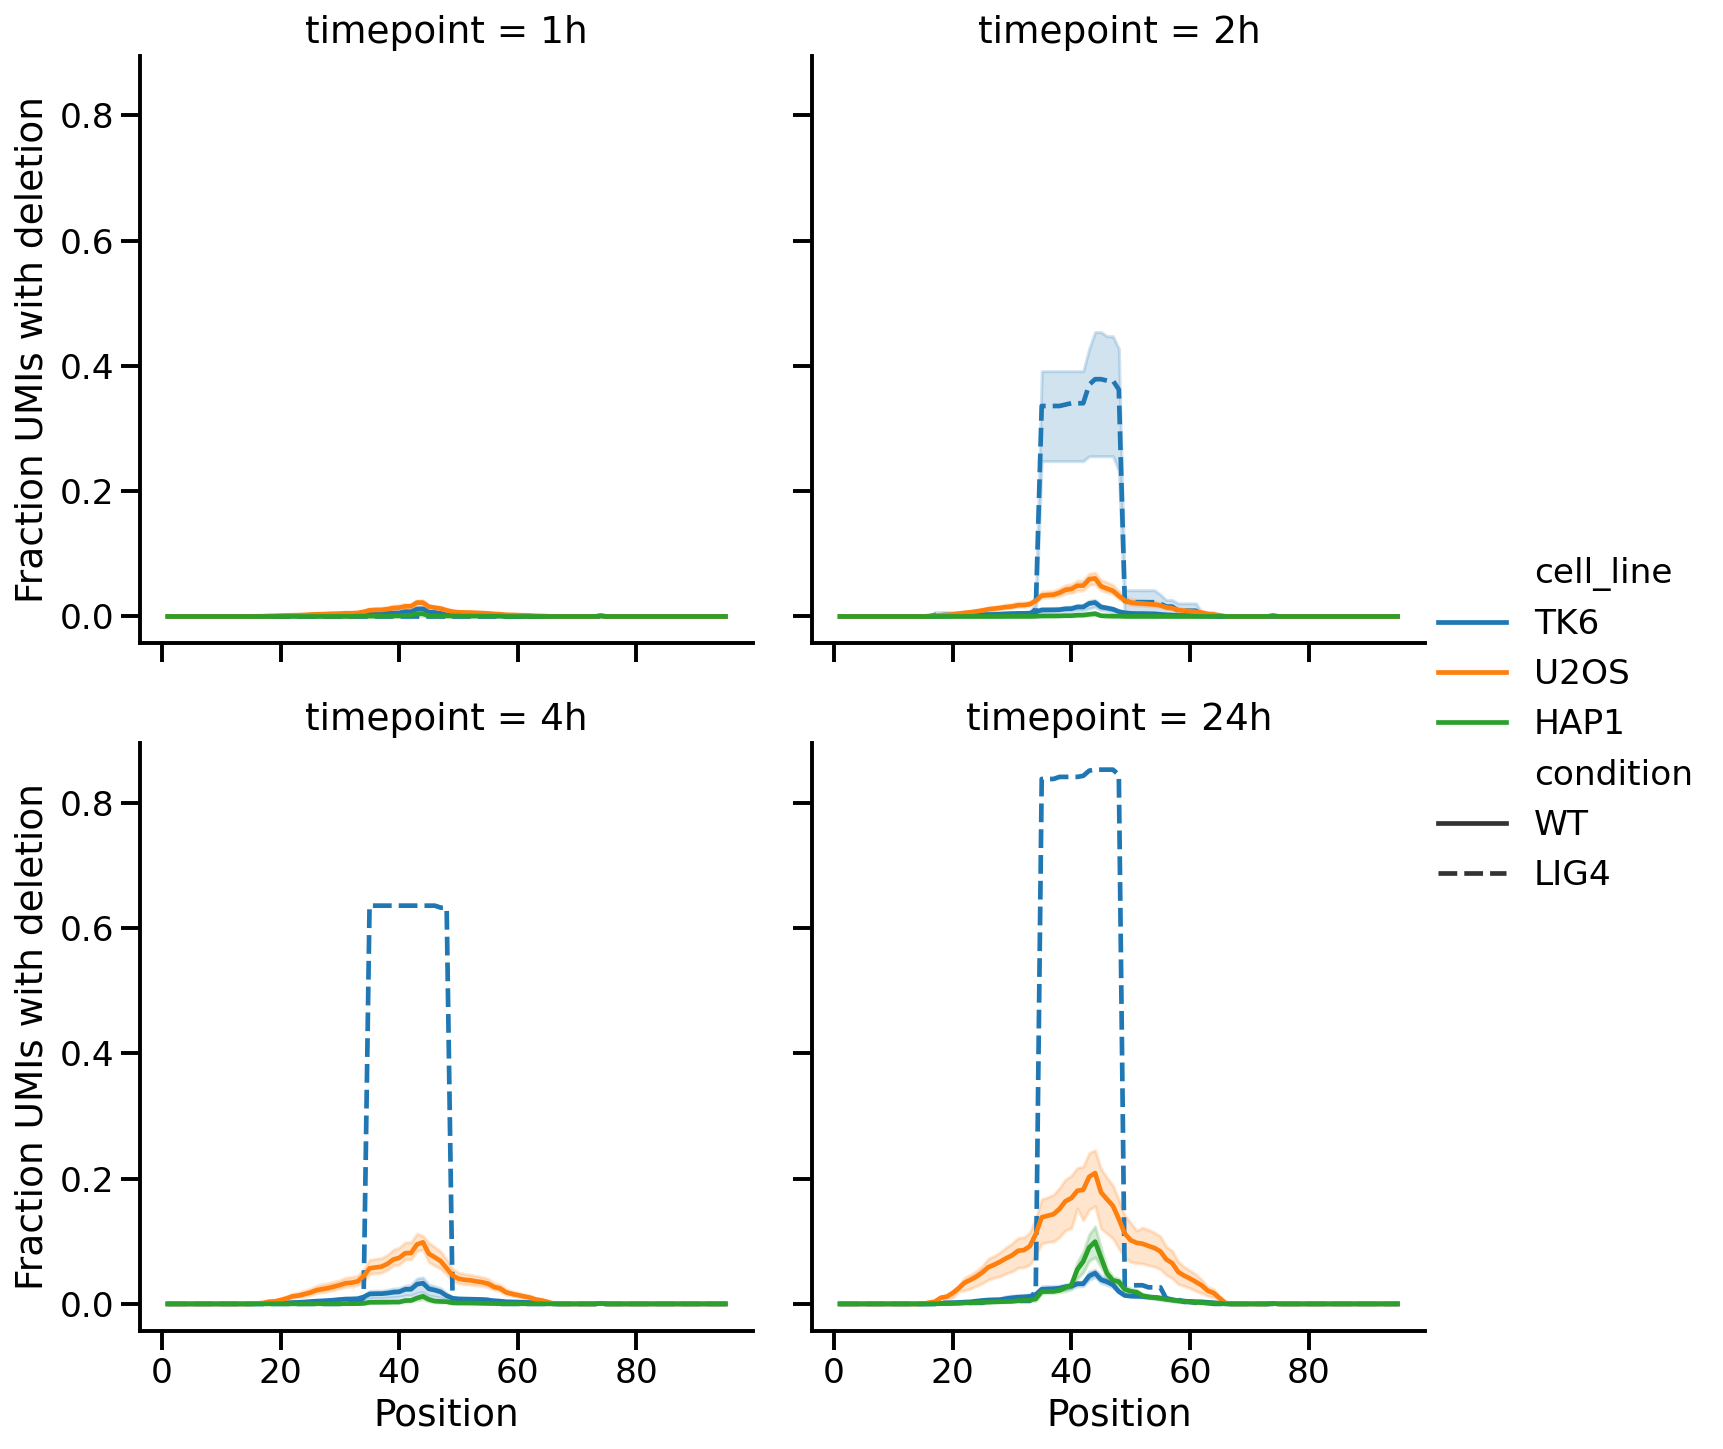

In [5]:
with sns.plotting_context("talk"):


    df[['cell_line','condition','timepoint','replicate']] = df['sample'].str.split('_',expand=True)
    df['name'] = df['cell_line'] + '_' + df['condition']

    idx = (df['contig']=='GFP_BAR_DSBR_2')&(df['condition'].isin(['WT','LIG4']))&(df['cell_line']!="U2OSPatty")
    g = sns.relplot(x="position",y="f_del",
            data=df[idx],
            col="timepoint",hue="cell_line",style='condition',kind='line',col_wrap = 2)

    g.set_axis_labels(x_var="Position", y_var="Fraction UMIs with deletion")
plt.savefig('pdf/figure3b_deletion_rate.pdf',bbox_inches="tight")

## Figure 3c - read-level MMEJ deletions

In [6]:
def plot_deletions(df,min_x = 1,
                   max_x = 100,
                   dsb_pos = 43.5,
                   lw_thin=1,
                   lw_thick=2,
                   fontsize=6,
                   ax=None,
                   figsize=(5,8),
                   max_show=100):
    
    if ax is None:
        f,ax = plt.subplots(1,figsize=figsize)

    if max_show < df.shape[0]:
        df = df.sample(max_show,random_state=0)
        
    df = df.sort_values(['deletion_length','start'])
        
    i=0
    for ind,row in df.iterrows():

        color = 'green' if row['microhomology_length']>=3 else 'grey'
        
        ax.plot([min_x,row['start']],[i,i],linewidth=lw_thick,color=color)
        ax.plot([row['start'],row['end']+1],[i,i],linewidth=lw_thin,color='grey')
        ax.plot([row['end']+1,max_x],[i,i],linewidth=lw_thick,color=color)
    
        mh_sequence = row['deleted_sequence'][0:row['microhomology_length']]
    
        ax.text(row['start']+1,i,mh_sequence,fontsize=fontsize,va='center_baseline',ha='left',fontweight='bold')
        ax.text(row['end']+1,i,mh_sequence,fontsize=fontsize,va='center_baseline',ha='left',fontweight='bold')
        
        ax.axvline(dsb_pos,linestyle='--',linewidth=1,color='red')
        
        ax.set_yticks([])

        i +=1 

In [7]:
df = pd.read_csv('../data/final_merged_set.deletions.csv')
df = df[df['contig']=='GFP_BAR_DSBR_2']

df[['cell_line','condition','timepoint','replicate']] = df['sample'].str.split('_',expand=True)

samples = [f'TK6_{c}_4h_BR0' for c in ['WT','LIG4','PolQ']]
df = df[df['sample'].isin(samples)]

df = df.sort_values(['sample','deletion_length','start'],ascending=True)

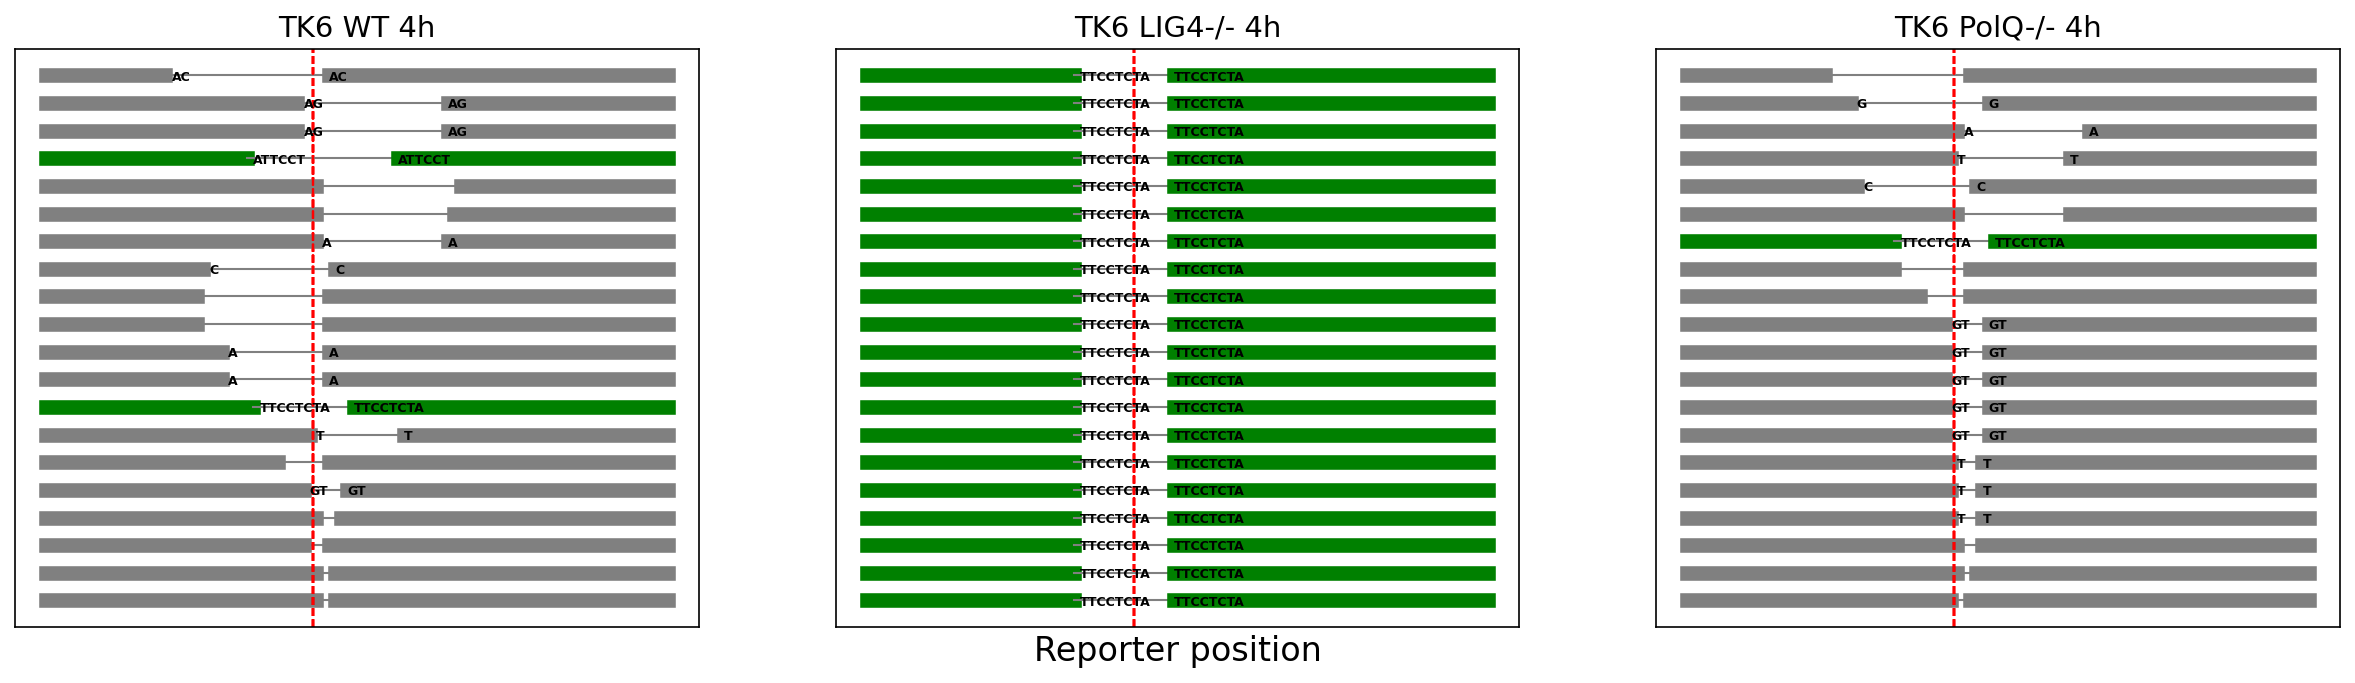

In [8]:
f,ax = plt.subplots(1,3,figsize=(20,5))

for i in range(0,len(samples)):
    plot_deletions(df[df['sample']==samples[i]],ax=ax[i],max_show=20,lw_thick=7)
    line,condition,timepoint,replicate = samples[i].split('_')

    if condition!='WT':
        condition = condition + '-/-'

    ax[i].set_title(f'{line} {condition} {timepoint}',fontsize=14)

    ax[i].set_xticks([])

ax[1].set_xlabel('Reporter position')
    
plt.savefig('pdf/figure3c_mmej_deletions.pdf',bbox_inches="tight")